Purpose of this notebook:
1) Load evidence outputs from Notebook 2
2) Define the leadership decision framework (criteria + weights)
3) Build a transparent feasibility model (synthetic but documented)
4) Assign defensible criterion scores for Supplier Quality
5) Compute the weighted prioritisation score
6) Run a quick sensitivity check (exceptional touch)
7) Save final tables for reporting

Inputs:
1) data/processed/supplier_risk_metrics.csv
2) data/processed/supplier_severity_table.csv

Outputs:
1) data/processed/decision_scores_supplier_quality.csv
2) data/processed/sensitivity_results.csv

In [1]:
import pandas as pd

In [2]:
# -----------------------------
# STEP 0: File paths
# -----------------------------
METRICS_PATH = "data/processed/supplier_risk_metrics.csv"
TABLE_PATH = "data/processed/supplier_severity_table.csv"

OUT_SCORE_PATH = "data/processed/decision_scores_supplier_quality.csv"
OUT_SENS_PATH = "data/processed/sensitivity_results.csv"

In [3]:
# -----------------------------
# STEP 1: Load evidence from Notebook 2
# -----------------------------
metrics = pd.read_csv(METRICS_PATH)
severity_table = pd.read_csv(TABLE_PATH)

print("Loaded evidence outputs")
display(metrics)
display(severity_table.head())

# Extract key numbers (guarded)
m = metrics.iloc[0].to_dict()

supplier_related_share_pct = float(m["supplier_related_share_pct"])
severe_supplier_pct = float(m["severe_supplier_pct_class_I_II"])

print("\n--- Evidence headlines ---")
print("Supplier-related share (%):", supplier_related_share_pct)
print("Severe supplier-linked recalls (% Class I/II):", severe_supplier_pct)

Loaded evidence outputs


,total_records,supplier_related_count,supplier_related_share_pct,severe_supplier_count_class_I_II,severe_supplier_pct_class_I_II,non_supplier_count,severe_non_supplier_count_class_I_II,severe_non_supplier_pct_class_I_II
0,503,401,79.72,385,96.01,102,91,89.22


,supplier_related_flag,Class I,Class II,Class III
0,False,9,82,11
1,True,199,186,16



--- Evidence headlines ---
Supplier-related share (%): 79.72
Severe supplier-linked recalls (% Class I/II): 96.01


In [4]:
# -----------------------------
# STEP 2: Define decision criteria and weights (locked)
# -----------------------------
weights = {
    "Risk Severity": 30,
    "Cost of Inaction": 25,
    "Detectability": 20,
    "Frequency": 15,
    "Feasibility": 10
}

# Sanity check
assert sum(weights.values()) == 100, "Weights must sum to 100"
print("\nWeights locked:", weights)


Weights locked: {'Risk Severity': 30, 'Cost of Inaction': 25, 'Detectability': 20, 'Frequency': 15, 'Feasibility': 10}


In [5]:
# -----------------------------
# STEP 3: Transparent feasibility model
# -----------------------------

feasibility_assumptions = pd.DataFrame([{
    "Process": "Supplier Quality Monitoring & Qualification",
    "Teams_Involved": 4,
    "Approval_Steps": 6,
    "Automation_Level": "Medium",
    "Change_Complexity_Notes": "Cross-functional approvals + moderate training + some automation possible"
}])

display(feasibility_assumptions)

feasibility_score = 3

,Process,Teams_Involved,Approval_Steps,Automation_Level,Change_Complexity_Notes
0,Supplier Quality Monitoring & Qualification,4,6,Medium,Cross-functional approvals + moderate training...


In [6]:
# -----------------------------
# STEP 4: Assign criterion scores for Supplier Quality (1–5)
# -----------------------------
risk_severity_score = 5 if severe_supplier_pct >= 90 else (4 if severe_supplier_pct >= 75 else 3)

scores = {
    "Risk Severity": risk_severity_score,
    "Cost of Inaction": 4,
    "Detectability": 4,
    "Frequency": 4,
    "Feasibility": feasibility_score
}

print("Scores assigned:", scores)

Scores assigned: {'Risk Severity': 5, 'Cost of Inaction': 4, 'Detectability': 4, 'Frequency': 4, 'Feasibility': 3}


In [7]:
# -----------------------------
# STEP 5: Compute weighted prioritisation score
# -----------------------------
weighted_score = sum(weights[k] * scores[k] for k in weights) / 100
print("Final Weighted Prioritisation Score:", round(weighted_score, 2))

# Create a decision table for reporting
decision_table = pd.DataFrame([{
    "Process": "Supplier Quality Monitoring & Qualification",
    **{f"{k} (weight {weights[k]})": scores[k] for k in weights},
    "Weighted_Score": round(weighted_score, 2)
}])

display(decision_table)

decision_table.to_csv(OUT_SCORE_PATH, index=False)
print(f"Saved decision score table to: {OUT_SCORE_PATH}")

Final Weighted Prioritisation Score: 4.2


,Process,Risk Severity (weight 30),Cost of Inaction (weight 25),Detectability (weight 20),Frequency (weight 15),Feasibility (weight 10),Weighted_Score
0,Supplier Quality Monitoring & Qualification,5,4,4,4,3,4.2


Saved decision score table to: data/processed/decision_scores_supplier_quality.csv


In [8]:
# -----------------------------
# STEP 6: Sensitivity check (this is what makes it exceptional)
# -----------------------------

scenarios = [
    {"Scenario": "Base", **weights},
    {"Scenario": "More Risk Focus", "Risk Severity": 35, "Cost of Inaction": 25, "Detectability": 20, "Frequency": 10, "Feasibility": 10},
    {"Scenario": "More Feasibility Focus", "Risk Severity": 28, "Cost of Inaction": 22, "Detectability": 20, "Frequency": 15, "Feasibility": 15},
    {"Scenario": "More Frequency Focus", "Risk Severity": 25, "Cost of Inaction": 25, "Detectability": 15, "Frequency": 25, "Feasibility": 10},
]

# Ensure each scenario sums to 100 (defensive check)
for s in scenarios:
    wsum = s["Risk Severity"] + s["Cost of Inaction"] + s["Detectability"] + s["Frequency"] + s["Feasibility"]
    if wsum != 100:
        raise ValueError(f"Scenario '{s['Scenario']}' weights do not sum to 100. Sum={wsum}")

sens_rows = []
for s in scenarios:
    w = {k: s[k] for k in weights.keys()}
    sc = sum(w[k] * scores[k] for k in w) / 100
    sens_rows.append({"Scenario": s["Scenario"], "Weighted_Score": round(sc, 2), **w})

sensitivity = pd.DataFrame(sens_rows).sort_values("Weighted_Score", ascending=False)
display(sensitivity)

sensitivity.to_csv(OUT_SENS_PATH, index=False)
print(f"Saved sensitivity results to: {OUT_SENS_PATH}")

,Scenario,Weighted_Score,Risk Severity,Cost of Inaction,Detectability,Frequency,Feasibility
1,More Risk Focus,4.25,35,25,20,10,10
0,Base,4.20,30,25,20,15,10
3,More Frequency Focus,4.15,25,25,15,25,10
2,More Feasibility Focus,4.13,28,22,20,15,15


Saved sensitivity results to: data/processed/sensitivity_results.csv


In [9]:
# -----------------------------
# STEP 7: Final recommendation text
# -----------------------------
recommendation = f"""
Final Recommendation:
Supplier Quality Monitoring & Qualification should be prioritised for leadership intervention.

Evidence:
- Supplier-linked recalls share: {supplier_related_share_pct}% of severity-classified recalls
- Severe supplier-linked recalls (Class I/II): {severe_supplier_pct}%

Decision Outcome:
- Base weighted prioritisation score: {round(weighted_score, 2)}/5
- Score remains high under multiple weighting scenarios (sensitivity check).
"""

print(recommendation)


Final Recommendation:
Supplier Quality Monitoring & Qualification should be prioritised for leadership intervention.

Evidence:
- Supplier-linked recalls share: 79.72% of severity-classified recalls
- Severe supplier-linked recalls (Class I/II): 96.01%

Decision Outcome:
- Base weighted prioritisation score: 4.2/5
- Score remains high under multiple weighting scenarios (sensitivity check).



In [10]:
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

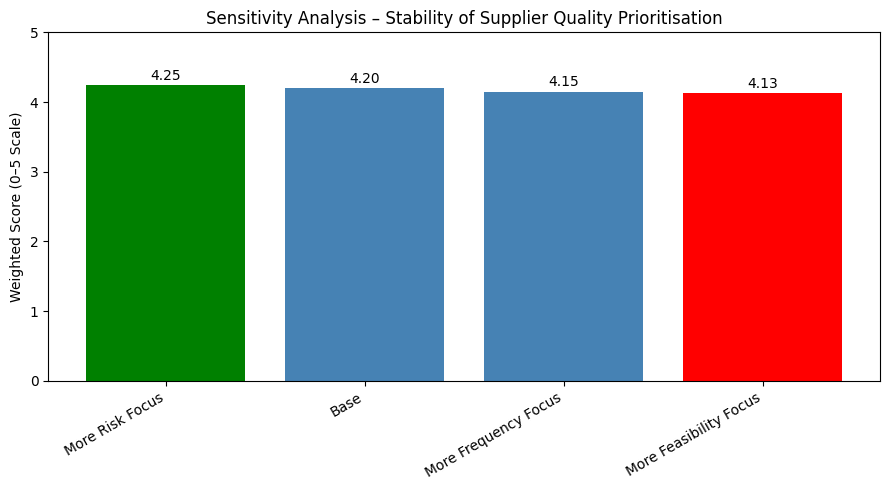

Saved: outputs\sensitivity_analysis.png


In [11]:
# -----------------------------------------
# Sensitivity Analysis Chart (Saved)
# -----------------------------------------

sensitivity_sorted = sensitivity.sort_values("Weighted_Score", ascending=False).reset_index(drop=True)

scores = sensitivity_sorted["Weighted_Score"]
scenarios = sensitivity_sorted["Scenario"]

max_score = scores.max()
min_score = scores.min()

colors = []
for s in scores:
    if s == max_score:
        colors.append("green")
    elif s == min_score:
        colors.append("red")
    else:
        colors.append("steelblue")

plt.figure(figsize=(9, 5))
bars = plt.bar(scenarios, scores, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Sensitivity Analysis – Stability of Supplier Quality Prioritisation")
plt.ylabel("Weighted Score (0–5 Scale)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 5)
plt.tight_layout()

sensitivity_path = os.path.join(OUTPUT_DIR, "sensitivity_analysis.png")
plt.savefig(sensitivity_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", sensitivity_path)

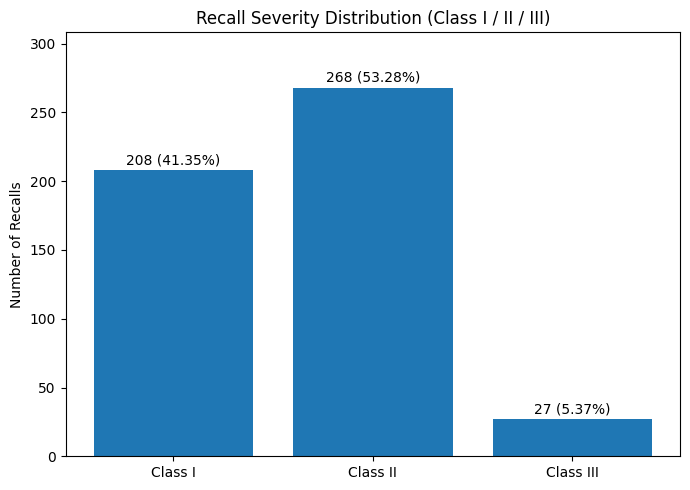

Saved: outputs\severity_distribution.png


In [12]:
# -----------------------------------------
# Severity Distribution Chart (Saved)
# -----------------------------------------

severity_df = pd.read_csv("data/processed/recalls_severity_clean.csv")

class_counts = severity_df["classification"].value_counts().reindex(["Class I", "Class II", "Class III"])
total = class_counts.sum()
class_pct = (class_counts / total * 100).round(2)

plt.figure(figsize=(7, 5))
bars = plt.bar(class_counts.index, class_counts.values)

# Add count + % labels
for i, bar in enumerate(bars):
    h = bar.get_height()
    label = f"{int(h)} ({class_pct.iloc[i]}%)"
    plt.text(bar.get_x() + bar.get_width()/2, h + 2, label, ha="center", va="bottom")

plt.title("Recall Severity Distribution (Class I / II / III)")
plt.ylabel("Number of Recalls")
plt.ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()

severity_path = os.path.join(OUTPUT_DIR, "severity_distribution.png")
plt.savefig(severity_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", severity_path)